# Adult Census Income Classification

### Objective

The objective of this project is to predict whether an individual's annual income exceeds $50,000 based on demographic and employment-related attributes using machine learning classification techniques.

---

Dataset:
Adult Census Income Dataset

Libraries:
- Pandas
- NumPy
- Matplotlib
- Scikit-learn

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [2]:
df = pd.read_csv("data/adult.csv")

df.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


In [3]:
print("Shape:", df.shape)

df.info()

Shape: (32561, 15)
<class 'pandas.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             32561 non-null  int64
 1   workclass       32561 non-null  str  
 2   fnlwgt          32561 non-null  int64
 3   education       32561 non-null  str  
 4   education.num   32561 non-null  int64
 5   marital.status  32561 non-null  str  
 6   occupation      32561 non-null  str  
 7   relationship    32561 non-null  str  
 8   race            32561 non-null  str  
 9   sex             32561 non-null  str  
 10  capital.gain    32561 non-null  int64
 11  capital.loss    32561 non-null  int64
 12  hours.per.week  32561 non-null  int64
 13  native.country  32561 non-null  str  
 14  income          32561 non-null  str  
dtypes: int64(6), str(9)
memory usage: 6.2 MB


In [4]:
df.isnull().sum()

age               0
workclass         0
fnlwgt            0
education         0
education.num     0
marital.status    0
occupation        0
relationship      0
race              0
sex               0
capital.gain      0
capital.loss      0
hours.per.week    0
native.country    0
income            0
dtype: int64

In [5]:
df.duplicated().sum()

np.int64(24)

In [6]:
df = df.drop_duplicates()

print(df.shape)

(32537, 15)


In [7]:
df.replace(" ?", np.nan, inplace=True)
df.replace("?", np.nan, inplace=True)

print(df.isnull().sum())

age                  0
workclass         1836
fnlwgt               0
education            0
education.num        0
marital.status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital.gain         0
capital.loss         0
hours.per.week       0
native.country     582
income               0
dtype: int64


In [8]:
df = df.dropna()

print(df.shape)

(30139, 15)


In [9]:
encoder = LabelEncoder()

for column in df.columns:
    if df[column].dtype == "object":
        df[column] = encoder.fit_transform(df[column])

df.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K
5,34,Private,216864,HS-grad,9,Divorced,Other-service,Unmarried,White,Female,0,3770,45,United-States,<=50K
6,38,Private,150601,10th,6,Separated,Adm-clerical,Unmarried,White,Male,0,3770,40,United-States,<=50K


In [10]:
X = df.drop("income", axis=1)
y = df["income"]

print(X.shape)
print(y.shape)

(30139, 14)
(30139,)


In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(24111, 14)
(6028, 14)


In [12]:
model = Sequential([
    Dense(64, activation="relu", input_shape=(X_train.shape[1],)),
    Dense(32, activation="relu"),
    Dense(1, activation="sigmoid")
])

In [13]:
model = Sequential([
    Dense(64, activation="relu", input_shape=(X_train.shape[1],)),
    Dense(32, activation="relu"),
    Dense(1, activation="sigmoid")
])

In [14]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [15]:
# One-hot encode all categorical columns
df = pd.get_dummies(df, drop_first=True)

# Convert boolean columns (True/False) to integers (1/0)
bool_cols = df.select_dtypes(include=["bool"]).columns
df[bool_cols] = df[bool_cols].astype(int)

df.head()

,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week,workclass_Local-gov,workclass_Private,workclass_Self-emp-inc,workclass_Self-emp-not-inc,...,native.country_Puerto-Rico,native.country_Scotland,native.country_South,native.country_Taiwan,native.country_Thailand,native.country_Trinadad&Tobago,native.country_United-States,native.country_Vietnam,native.country_Yugoslavia,income_>50K
1,82,132870,9,0,4356,18,0,1,0,0,...,0,0,0,0,0,0,1,0,0,0
3,54,140359,4,0,3900,40,0,1,0,0,...,0,0,0,0,0,0,1,0,0,0
4,41,264663,10,0,3900,40,0,1,0,0,...,0,0,0,0,0,0,1,0,0,0
5,34,216864,9,0,3770,45,0,1,0,0,...,0,0,0,0,0,0,1,0,0,0
6,38,150601,6,0,3770,40,0,1,0,0,...,0,0,0,0,0,0,1,0,0,0


In [16]:
X = df.drop("income_>50K", axis=1)
y = df["income_>50K"]

In [17]:
print(X.shape)
print(y.shape)

(30139, 96)
(30139,)


In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [19]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [20]:
model = Sequential([
    Dense(64, activation="relu", input_shape=(X_train.shape[1],)),
    Dense(32, activation="relu"),
    Dense(1, activation="sigmoid")
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [21]:
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/20
603/603 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8282 - loss: 0.3649 - val_accuracy: 0.8428 - val_loss: 0.3343
Epoch 2/20
603/603 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8454 - loss: 0.3278 - val_accuracy: 0.8451 - val_loss: 0.3291
Epoch 3/20
603/603 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8507 - loss: 0.3161 - val_accuracy: 0.8420 - val_loss: 0.3257
Epoch 4/20
603/603 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8534 - loss: 0.3112 - val_accuracy: 0.8457 - val_loss: 0.3230
Epoch 5/20
603/603 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8569 - loss: 0.3054 - val_accuracy: 0.8447 - val_loss: 0.3252
Epoch 6/20
603/603 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8576 - loss: 0.3020 - val_accuracy: 0.8472 - val_loss: 0.3236
Epoch 7/20
603/603 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8613 - loss: 0.2984 - val_accuracy: 0.8437 - val_loss: 0.3266
Epoch 8/20
603/603 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8617 - loss: 0.2955 - val_accuracy: 0.

In [22]:
loss, accuracy = model.evaluate(X_test, y_test)

print("Test Loss:", loss)
print("Test Accuracy:", accuracy)

189/189 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8421 - loss: 0.3586
Test Loss: 0.3586173355579376
Test Accuracy: 0.8420703411102295


In [23]:
y_pred = model.predict(X_test)
y_pred = (y_pred > 0.5).astype(int)

189/189 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [24]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.89      0.91      0.90      4580
           1       0.69      0.63      0.66      1448

    accuracy                           0.84      6028
   macro avg       0.79      0.77      0.78      6028
weighted avg       0.84      0.84      0.84      6028



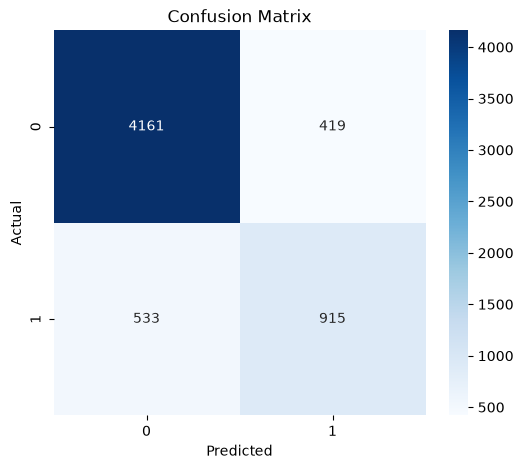

In [25]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

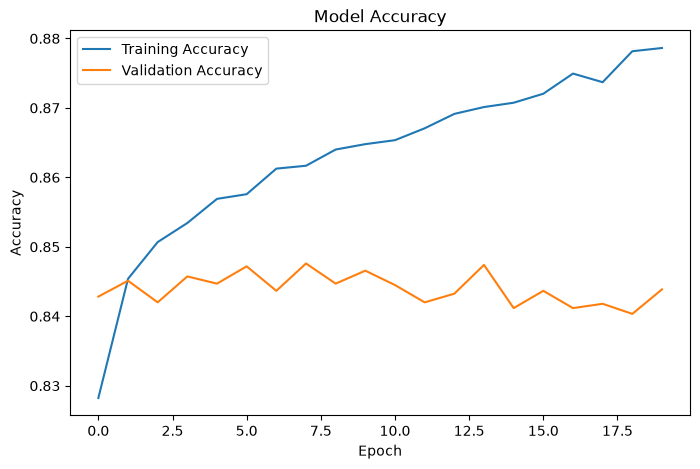

In [26]:
plt.figure(figsize=(8,5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

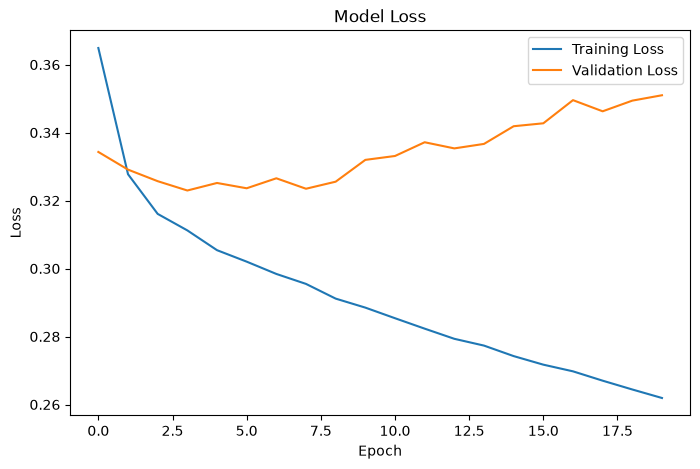

In [27]:
plt.figure(figsize=(8,5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [28]:
model.save("adult_income_classifier.keras")

## Conclusion

- Successfully preprocessed the Adult Census Income dataset.
- Applied one-hot encoding to categorical variables.
- Built and trained an Artificial Neural Network using TensorFlow/Keras.
- Evaluated the model using accuracy, classification report, and confusion matrix.
- Saved the trained model for future inference.